# Final Conclusions 

## Key Findings

• **Minimal velocity impact**: Fastball velocity differences across rest intervals are generally small, with most outings remaining within ±0.2 mph of a pitcher's baseline, regardless of rest days (0-5 days).

• **Workload matters more than rest**: Higher previous outing pitch counts (31+ pitches) are associated with slightly larger decreases in velocity and pitch quality in the following appearance, particularly with only 1 day of rest.

• **Back-to-back appearances show resilience**: Even with 0 days of rest (consecutive game appearances), relievers maintain relatively consistent pitch characteristics across velocity, spin rate, and movement metrics.

• **Spin rate stability**: Fastball and slider spin rates show minimal deviation from pitcher baselines across all rest day and workload combinations, suggesting spin generation is less affected by fatigue than other metrics.

• **Movement consistency**: Total pitch movement (horizontal + vertical) for both fastballs and sliders remains remarkably stable across rest intervals, with deviations typically under 1 inch from season averages.

• **Recovery patterns**: The largest declines in pitch quality occur when pitchers throw 31+ pitches and return with only 1 day of rest, but additional rest (2-5 days) shows diminishing returns in performance recovery.

• **Sample size considerations**: Back-to-back appearances (0 days rest) represent a smaller sample size, particularly for high-workload outings, as teams typically manage pitcher usage to avoid this scenario after heavy workloads.

In [2]:
from plotnine import *
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
# Global ggplot style: white background, no grid lines
theme_set(
    theme_bw() + theme(
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        panel_background=element_rect(fill="white"),
        plot_background=element_rect(fill="white"),
        legend_key=element_rect(fill="white", color="white"),
    )
)

In [4]:
(relieverss := pl.read_parquet("data/statcast_relievers_final.parquet"))

pitcher_id,date,game_id,velocity,spin_rate,pitch_type_abbr,pitch_type,pitch_result,ab_result,pitch_call,strike_zone,ball_count,strike_count,outs,inning,top_bottom,home_team,away_team,ab_number,pitch_num,batted_ball_type,runner_1b,runner_2b,runner_3b,away_score,home_score,defense_score,offense_score,game_type,batter_side,pitcher_hand,pitcher_days_since_prev_game,pitcher_days_until_next_game,horizontal_movement,vertical_movement,plate_x_position,plate_z_position,year,pitcher_name
i64,datetime[ns],i64,f64,i64,str,str,str,str,str,i64,i64,i64,i64,i64,str,str,str,i64,i64,str,i64,i64,i64,i64,i64,i64,i64,str,str,str,i64,i64,f64,f64,f64,f64,i32,str
433589,2021-04-01 00:00:00,634640,85.8,1989,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",11,0,0,2,6,"""Top""","""ATH""","""HOU""",41,1,null,null,670541,null,3,0,0,3,"""R""","""R""","""R""",null,3,-0.58,1.36,-0.88,3.62,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,87.5,2182,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",12,0,0,1,6,"""Top""","""ATH""","""HOU""",39,1,null,663656,608324,null,1,0,0,1,"""R""","""R""","""R""",null,3,-0.5,1.58,1.87,3.41,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,85.6,2136,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",11,0,0,2,6,"""Top""","""ATH""","""HOU""",40,1,null,663656,608324,null,1,0,0,1,"""R""","""L""","""R""",null,3,-0.49,1.4,-1.89,3.07,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,72.4,1772,"""CU""","""Curveball""","""called_strike""",null,"""S""",5,1,0,2,6,"""Top""","""ATH""","""HOU""",41,2,null,null,670541,null,3,0,0,3,"""R""","""R""","""R""",null,3,1.3,-0.06,0.27,2.94,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,87.2,2153,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",14,1,0,1,6,"""Top""","""ATH""","""HOU""",39,2,null,663656,608324,null,1,0,0,1,"""R""","""R""","""R""",null,3,-0.64,1.43,1.44,2.54,2021,"""Yusmeiro Petit"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
702352,2024-09-28 00:00:00,745281,94.7,1861,"""SI""","""Sinker""","""foul""",null,"""S""",4,2,2,0,9,"""Top""","""SF""","""STL""",80,5,null,695336,null,null,5,6,6,5,"""R""","""R""","""R""",3,null,-1.5,0.24,-0.79,2.38,2024,"""Spencer Bivens"""
702352,2024-09-28 00:00:00,745281,89.3,1631,"""CH""","""Changeup""","""blocked_ball""",null,"""B""",13,2,2,1,9,"""Top""","""SF""","""STL""",81,5,null,695336,null,null,5,6,6,5,"""R""","""L""","""R""",3,null,-0.89,0.32,-0.2,1.2,2024,"""Spencer Bivens"""
702352,2024-09-28 00:00:00,745281,92.3,2002,"""FC""","""Cutter""","""called_strike""","""strikeout""","""S""",12,2,2,0,9,"""Top""","""SF""","""STL""",80,6,null,695336,null,null,5,6,6,5,"""R""","""R""","""R""",3,null,0.02,0.73,0.67,3.32,2024,"""Spencer Bivens"""


In [5]:
(relievers := pl.read_parquet("data/statcast_relievers.parquet"))

pitcher_id,date,game_id,velocity,spin_rate,pitch_type_abbr,pitch_type,pitch_result,ab_result,pitch_call,strike_zone,ball_count,strike_count,outs,inning,top_bottom,home_team,away_team,ab_number,pitch_num,batted_ball_type,runner_1b,runner_2b,runner_3b,away_score,home_score,defense_score,offense_score,game_type,batter_side,pitcher_hand,pitcher_days_since_prev_game,pitcher_days_until_next_game,year,pitcher_name
i64,datetime[ns],i64,f64,i64,str,str,str,str,str,i64,i64,i64,i64,i64,str,str,str,i64,i64,str,i64,i64,i64,i64,i64,i64,i64,str,str,str,i64,i64,i32,str
433589,2021-04-01 00:00:00,634640,85.8,1989,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",11,0,0,2,6,"""Top""","""ATH""","""HOU""",41,1,null,null,670541,null,3,0,0,3,"""R""","""R""","""R""",null,3,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,87.5,2182,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",12,0,0,1,6,"""Top""","""ATH""","""HOU""",39,1,null,663656,608324,null,1,0,0,1,"""R""","""R""","""R""",null,3,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,85.6,2136,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",11,0,0,2,6,"""Top""","""ATH""","""HOU""",40,1,null,663656,608324,null,1,0,0,1,"""R""","""L""","""R""",null,3,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,72.4,1772,"""CU""","""Curveball""","""called_strike""",null,"""S""",5,1,0,2,6,"""Top""","""ATH""","""HOU""",41,2,null,null,670541,null,3,0,0,3,"""R""","""R""","""R""",null,3,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,87.2,2153,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",14,1,0,1,6,"""Top""","""ATH""","""HOU""",39,2,null,663656,608324,null,1,0,0,1,"""R""","""R""","""R""",null,3,2021,"""Yusmeiro Petit"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
702352,2024-09-28 00:00:00,745281,94.7,1861,"""SI""","""Sinker""","""foul""",null,"""S""",4,2,2,0,9,"""Top""","""SF""","""STL""",80,5,null,695336,null,null,5,6,6,5,"""R""","""R""","""R""",3,null,2024,"""Spencer Bivens"""
702352,2024-09-28 00:00:00,745281,89.3,1631,"""CH""","""Changeup""","""blocked_ball""",null,"""B""",13,2,2,1,9,"""Top""","""SF""","""STL""",81,5,null,695336,null,null,5,6,6,5,"""R""","""L""","""R""",3,null,2024,"""Spencer Bivens"""
702352,2024-09-28 00:00:00,745281,92.3,2002,"""FC""","""Cutter""","""called_strike""","""strikeout""","""S""",12,2,2,0,9,"""Top""","""SF""","""STL""",80,6,null,695336,null,null,5,6,6,5,"""R""","""R""","""R""",3,null,2024,"""Spencer Bivens"""


In [6]:
complete_outing_table = pl.read_parquet("data/complete_outing_table.parquet")
summary_table = pl.read_csv("data/rest_pitch_summary_table_days_bin.csv")

In [7]:
(complete_outing_table := pl.read_parquet("data/complete_outing_table.parquet"))

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation,pitches_last_1d,pitches_last_2d,pitches_last_3d,pitches_last_4d,pitches_last_5d,pitches_last_6d,season_avg_h_movement,season_avg_v_movement,h_movement_deviation,v_movement_deviation,prev_pitch_bin,current_pitch_bin,abs_velo_deviation,strike_pct,season_avg_strike_pct,strike_pct_deviation,first_pitch_strike_pct,season_avg_fp_strike_pct,fp_strike_pct_deviation
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543,null,null,null,null,null,null,-0.313921,1.491772,-0.013579,0.044061,"""21-30""","""11-20""",1.524306,0.5625,0.675712,-0.113212,0.25,0.633114,-0.383114
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876,16,16,16,16,16,16,-0.313921,1.491772,-0.011079,-0.009272,"""11-20""","""≤10""",1.840973,0.6,0.675712,-0.075712,0.333333,0.633114,-0.299781
433589,634537,2021-04-09 00:00:00,2021,"""Yusmeiro Petit""",8,86.1375,89.2,2141.5,-0.31375,1.555,7,"""R""",0,2,8,10,86.615973,2137.198876,-0.478473,4.301124,null,10,26,26,26,26,-0.313921,1.491772,0.000171,0.063228,"""≤10""","""≤10""",0.478473,0.875,0.675712,0.199288,1.0,0.633114,0.366886
433589,632231,2021-04-12 00:00:00,2021,"""Yusmeiro Petit""",7,86.357143,87.7,2242.0,-0.18,1.548571,6,"""R""",3,3,10,8,86.615973,2137.198876,-0.25883,104.801124,null,null,8,8,18,34,-0.313921,1.491772,0.133921,0.056799,"""≤10""","""≤10""",0.25883,0.6,0.675712,-0.075712,0.5,0.633114,-0.133114
433589,632206,2021-04-13 00:00:00,2021,"""Yusmeiro Petit""",4,86.7,88.3,2058.5,-0.0875,1.3625,7,"""R""",0,1,6,10,86.615973,2137.198876,0.084027,-78.698876,10,10,10,18,18,28,-0.313921,1.491772,0.226421,-0.129272,"""≤10""","""≤10""",0.084027,0.666667,0.675712,-0.009045,0.0,0.633114,-0.633114
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
702352,746985,2024-09-19 00:00:00,2024,"""Spencer Bivens""",32,94.1,97.5,2093.96875,-0.650938,0.590938,8,"""R""",-1,4,37,13,94.048879,1941.835625,0.051121,152.133125,null,null,null,13,13,13,-1.036227,0.51891,0.38529,0.072027,"""11-20""","""31+""",0.051121,0.621622,0.655255,-0.033633,0.5,0.637626,-0.137626
702352,746255,2024-09-21 00:00:00,2024,"""Spencer Bivens""",18,95.127778,97.2,2105.0,-0.842222,0.501667,7,"""R""",9,2,28,37,94.048879,1941.835625,1.078899,163.164375,null,37,37,37,37,50,-1.036227,0.51891,0.194005,-0.017243,"""31+""","""21-30""",1.078899,0.678571,0.655255,0.023316,0.75,0.637626,0.112374
702352,747150,2024-09-23 00:00:00,2024,"""Spencer Bivens""",14,94.907143,97.1,2092.5,-0.977857,0.445714,6,"""R""",3,2,21,28,94.048879,1941.835625,0.858264,150.664375,null,28,28,65,65,65,-1.036227,0.51891,0.05837,-0.073196,"""21-30""","""21-30""",0.858264,0.619048,0.655255,-0.036207,0.5,0.637626,-0.137626


In [8]:
complete_outing_table_no_nulls = complete_outing_table.drop_nulls()
complete_outing_table_no_nulls.head()

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation,pitches_last_1d,pitches_last_2d,pitches_last_3d,pitches_last_4d,pitches_last_5d,pitches_last_6d,season_avg_h_movement,season_avg_v_movement,h_movement_deviation,v_movement_deviation,prev_pitch_bin,current_pitch_bin,abs_velo_deviation,strike_pct,season_avg_strike_pct,strike_pct_deviation,first_pitch_strike_pct,season_avg_fp_strike_pct,fp_strike_pct_deviation
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876,16,16,16,16,16,16,-0.313921,1.491772,-0.011079,-0.009272,"""11-20""","""≤10""",1.840973,0.6,0.675712,-0.075712,0.333333,0.633114,-0.299781
433589,632206,2021-04-13 00:00:00,2021,"""Yusmeiro Petit""",4,86.7,88.3,2058.5,-0.0875,1.3625,7,"""R""",0,1,6,10,86.615973,2137.198876,0.084027,-78.698876,10,10,10,18,18,28,-0.313921,1.491772,0.226421,-0.129272,"""≤10""","""≤10""",0.084027,0.666667,0.675712,-0.009045,0.0,0.633114,-0.633114
433589,634525,2021-04-16 00:00:00,2021,"""Yusmeiro Petit""",13,85.992308,87.9,2126.076923,-0.329231,1.502308,7,"""R""",2,1,19,13,86.615973,2137.198876,-0.623665,-11.121953,13,13,19,29,29,29,-0.313921,1.491772,-0.01531,0.010536,"""11-20""","""11-20""",0.623665,0.684211,0.675712,0.008499,0.75,0.633114,0.116886
433589,634381,2021-04-30 00:00:00,2021,"""Yusmeiro Petit""",11,84.536364,86.6,2068.181818,-0.325455,1.572727,9,"""R""",-1,1,15,16,86.615973,2137.198876,-2.079609,-69.017058,16,16,16,42,42,42,-0.313921,1.491772,-0.011534,0.080955,"""11-20""","""11-20""",2.079609,0.666667,0.675712,-0.009045,0.75,0.633114,0.116886
433589,634236,2021-05-08 00:00:00,2021,"""Yusmeiro Petit""",12,88.175,90.0,2138.25,-0.598333,1.486667,6,"""R""",1,1,16,10,86.615973,2137.198876,1.559027,1.051124,10,10,10,27,27,39,-0.313921,1.491772,-0.284413,-0.005105,"""≤10""","""11-20""",1.559027,0.8125,0.675712,0.136788,0.8,0.633114,0.166886


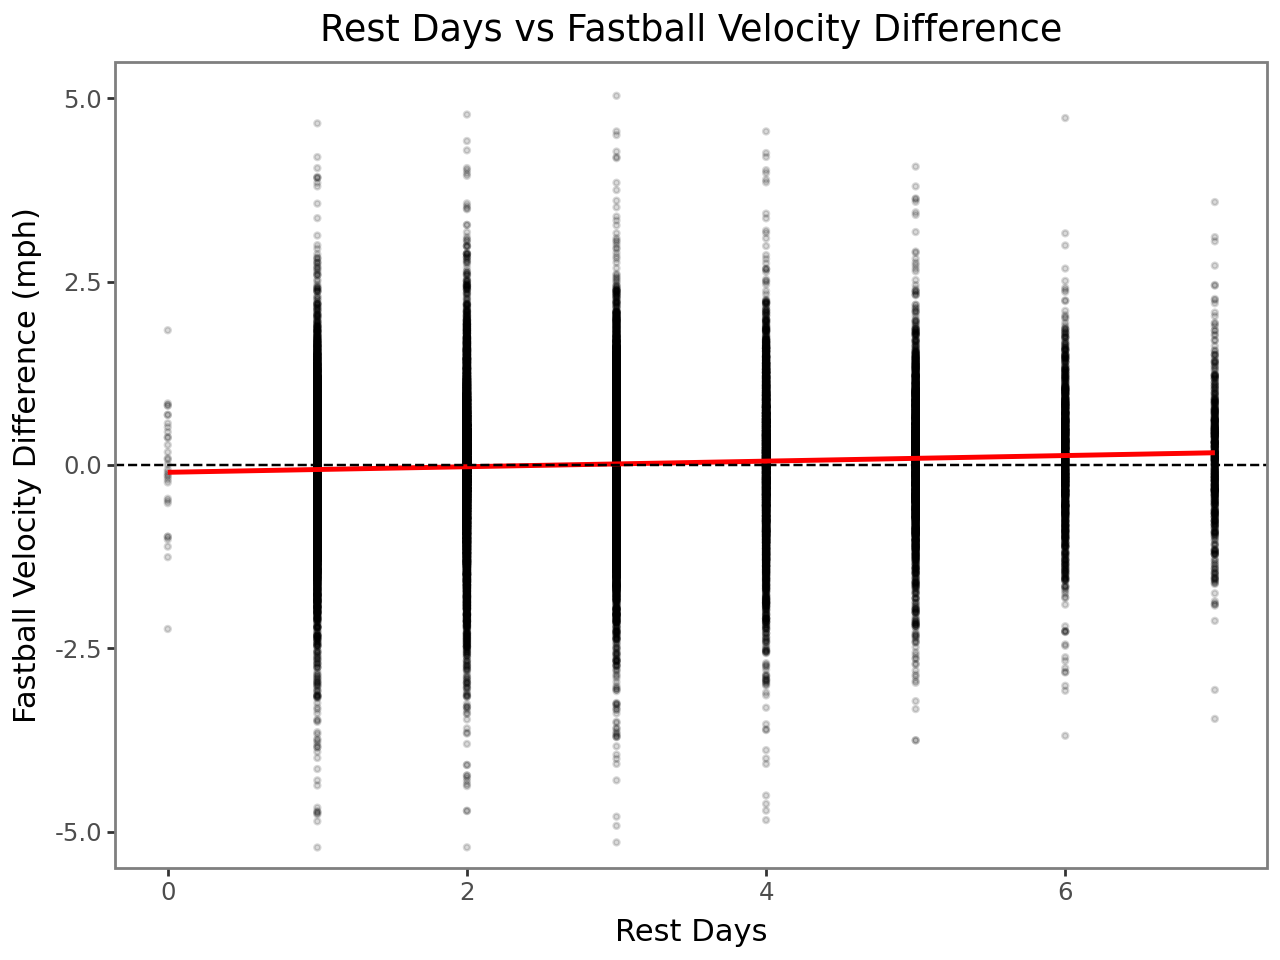

In [9]:
(
    ggplot(complete_outing_table, aes(x='rest_days', y='velo_deviation')) +
    geom_point(alpha=0.15, size=0.7) +
    geom_smooth(method='lm', se=True, color='red') +
    coord_cartesian(ylim=(-5, 5)) +
    geom_hline(yintercept=0, linetype='dashed') +
    labs(
        title='Rest Days vs Fastball Velocity Difference',
        x='Rest Days',
        y='Fastball Velocity Difference (mph)'
    ) 
)

C:\Users\kh6102sj\AppData\Local\Temp\ipykernel_22276\3331908495.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


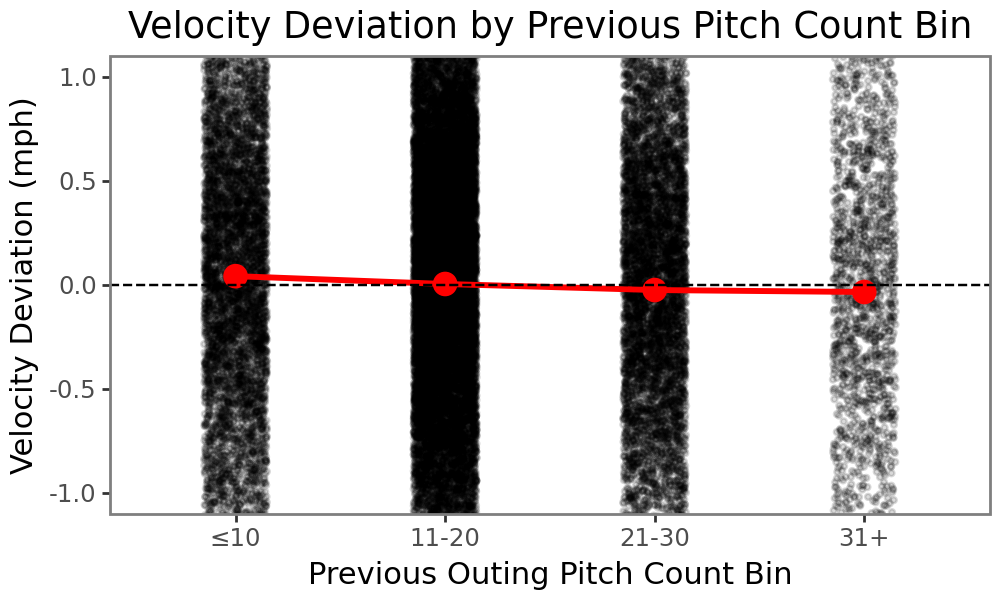

In [10]:
plot_df = (
    complete_outing_table
    .select(["prev_pitch_bin", "velo_deviation"])
    .drop_nulls(["prev_pitch_bin", "velo_deviation"])
    .to_pandas()
)

# Ensure correct order
order = ["≤10", "11-20", "21-30", "31+"]
plot_df["prev_pitch_bin"] = pd.Categorical(
    plot_df["prev_pitch_bin"],
    categories=order,
    ordered=True
)

# Compute means
mean_df = (
    plot_df
    .groupby("prev_pitch_bin", as_index=False)
    .mean(numeric_only=True)
)

(
    ggplot(plot_df, aes(x="prev_pitch_bin", y="velo_deviation")) +
    geom_jitter(alpha=0.15, width=0.15, size=0.7) +
    geom_line(
        data=mean_df,
        mapping=aes(x="prev_pitch_bin", y="velo_deviation", group=1),
        color="red",
        size=1.2
    ) +
    geom_point(
        data=mean_df,
        mapping=aes(x="prev_pitch_bin", y="velo_deviation"),
        color="red",
        size=4
    ) +
    geom_hline(yintercept=0, linetype="dashed") +
    coord_cartesian(ylim=(-1, 1)) +
    labs(
        title="Velocity Deviation by Previous Pitch Count Bin",
        x="Previous Outing Pitch Count Bin",
        y="Velocity Deviation (mph)"
    ) 
    + theme(figure_size=(5, 3))
)

In [11]:
import numpy as np

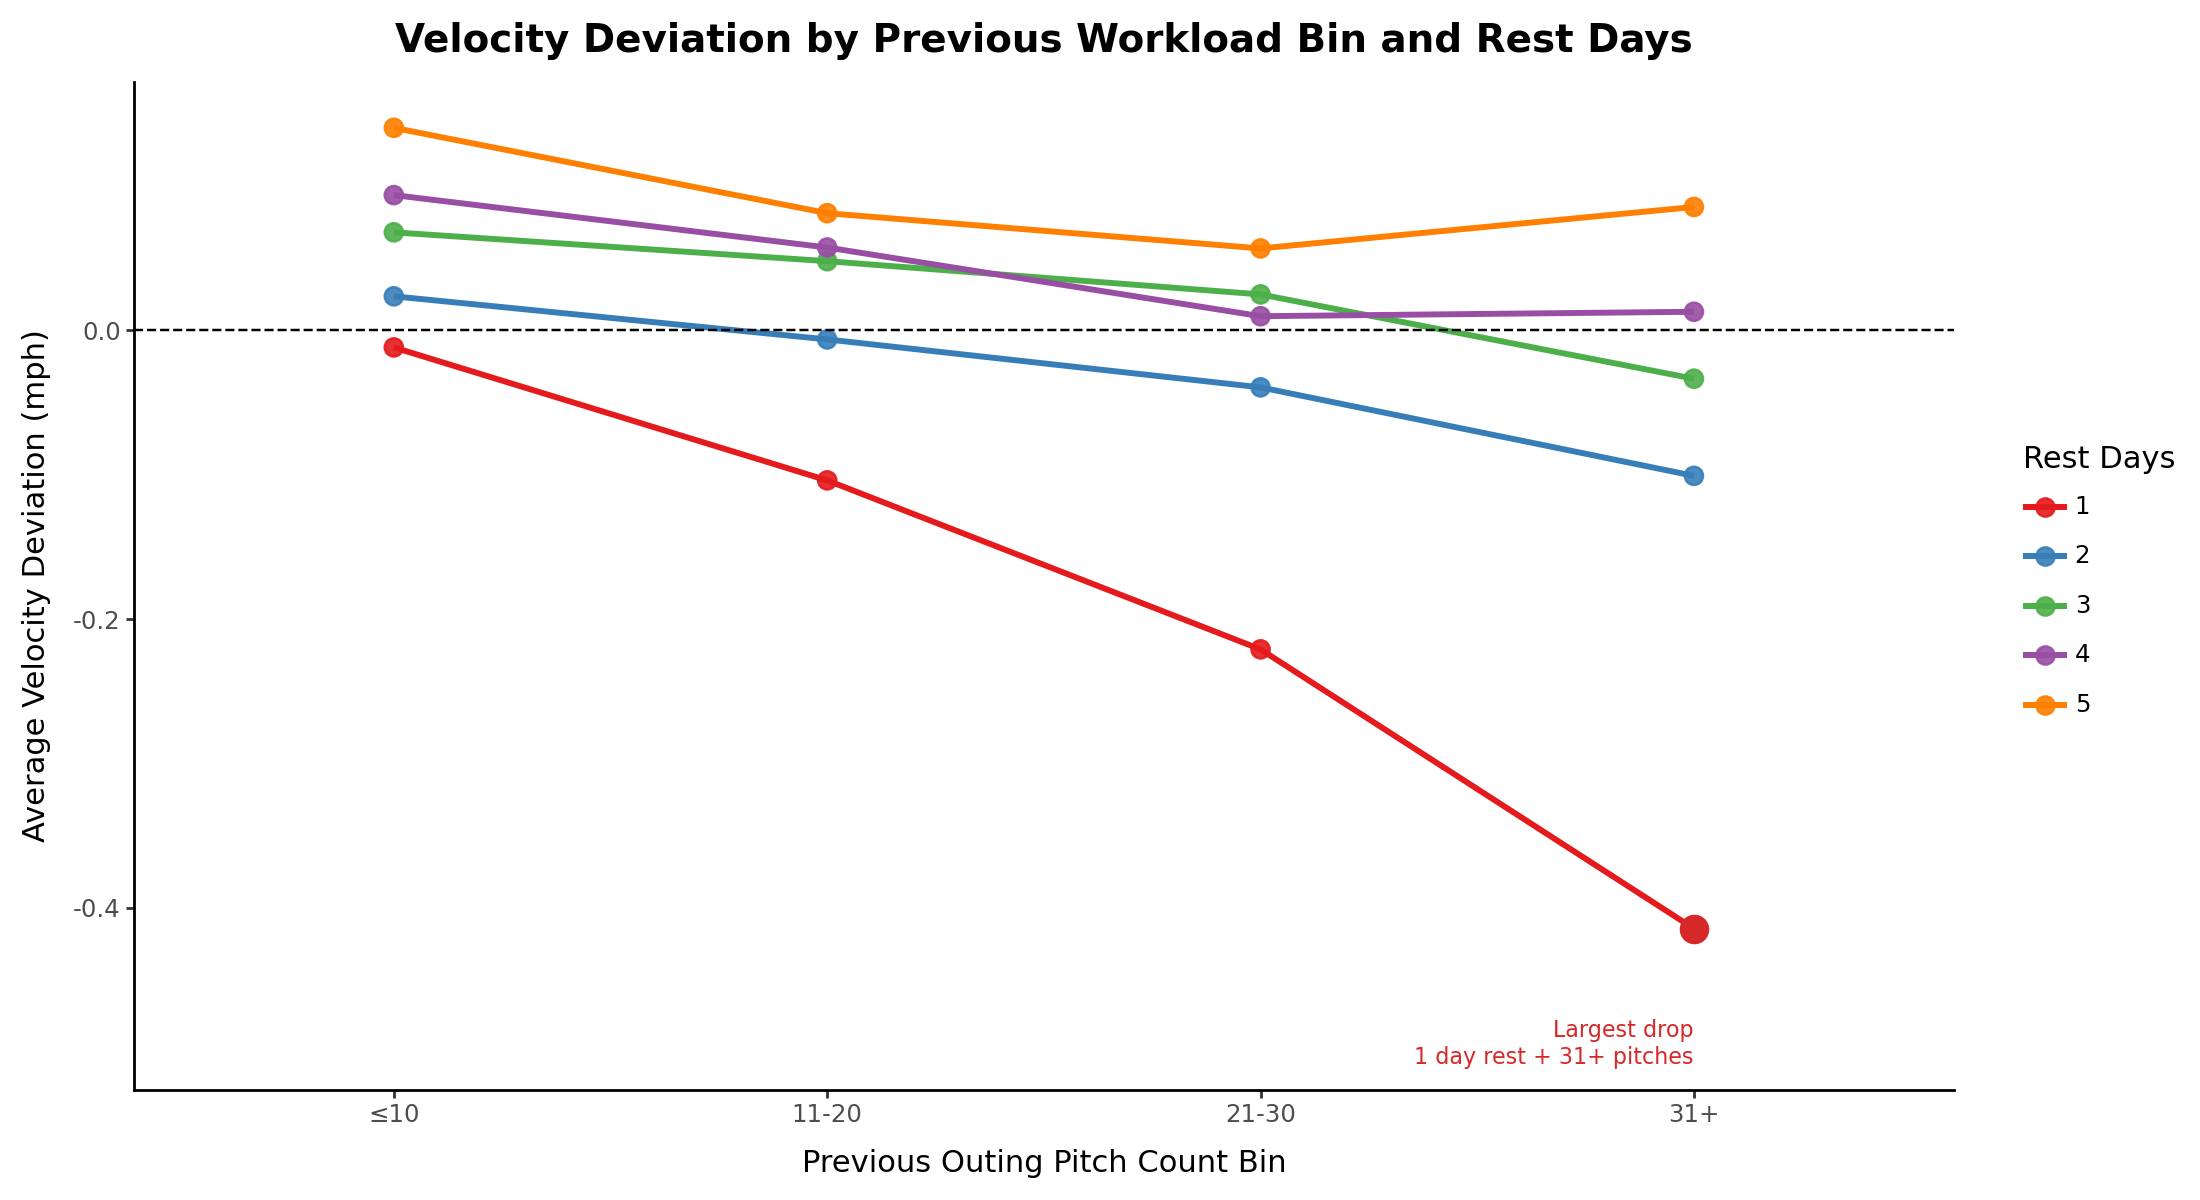

In [12]:
# Clean summary chart for slide use: mean velocity deviation by workload bin, grouped by rest days
summary_plot_data = (
    complete_outing_table
    .filter(
        pl.col("rest_days").is_between(1, 5)
        & pl.col("prev_pitch_bin").is_not_null()
        & pl.col("velo_deviation").is_not_null()
    )
    .group_by(["rest_days", "prev_pitch_bin"])
    .agg([
        pl.mean("velo_deviation").alias("avg_velo_deviation"),
        pl.len().alias("n")
    ])
    .to_pandas()
)

bin_order = ["≤10", "11-20", "21-30", "31+"]
summary_plot_data["prev_pitch_bin"] = pd.Categorical(
    summary_plot_data["prev_pitch_bin"],
    categories=bin_order,
    ordered=True
)
summary_plot_data = summary_plot_data.sort_values(["rest_days", "prev_pitch_bin"])
highlight_point = summary_plot_data[
    (summary_plot_data["rest_days"] == 1) & (summary_plot_data["prev_pitch_bin"] == "31+")
] .iloc[0]

(
    ggplot(summary_plot_data, aes(x="prev_pitch_bin", y="avg_velo_deviation", group="factor(rest_days)", color="factor(rest_days)"))
    + geom_line(size=1.2)
    + geom_point(size=3.2, alpha=0.9)
    + geom_hline(yintercept=0, linetype="dashed", color="black")
    + geom_point(
        data=summary_plot_data.query("rest_days == 1 and prev_pitch_bin == '31+'"),
        mapping=aes(x="prev_pitch_bin", y="avg_velo_deviation"),
        size=5,
        color="#D62828"
    )
    + annotate(
        "text",
        x=4,
        y=float(highlight_point["avg_velo_deviation"]) - 0.08,
        label="Largest drop\n1 day rest + 31+ pitches",
        size=8,
        color="#D62828",
        ha="right"
    )
    + scale_color_brewer(type="qual", palette="Set1")
    + labs(
        title="Velocity Deviation by Previous Workload Bin and Rest Days",
        x="Previous Outing Pitch Count Bin",
        y="Average Velocity Deviation (mph)",
        color="Rest Days"
    )
    + theme_classic()
    + theme(
        figure_size=(11, 6),
        legend_position="right",
        axis_text_x=element_text(rotation=0),
        plot_title=element_text(weight="bold", size=14),
        legend_key=element_rect(fill="white", color="white"),
    )
)

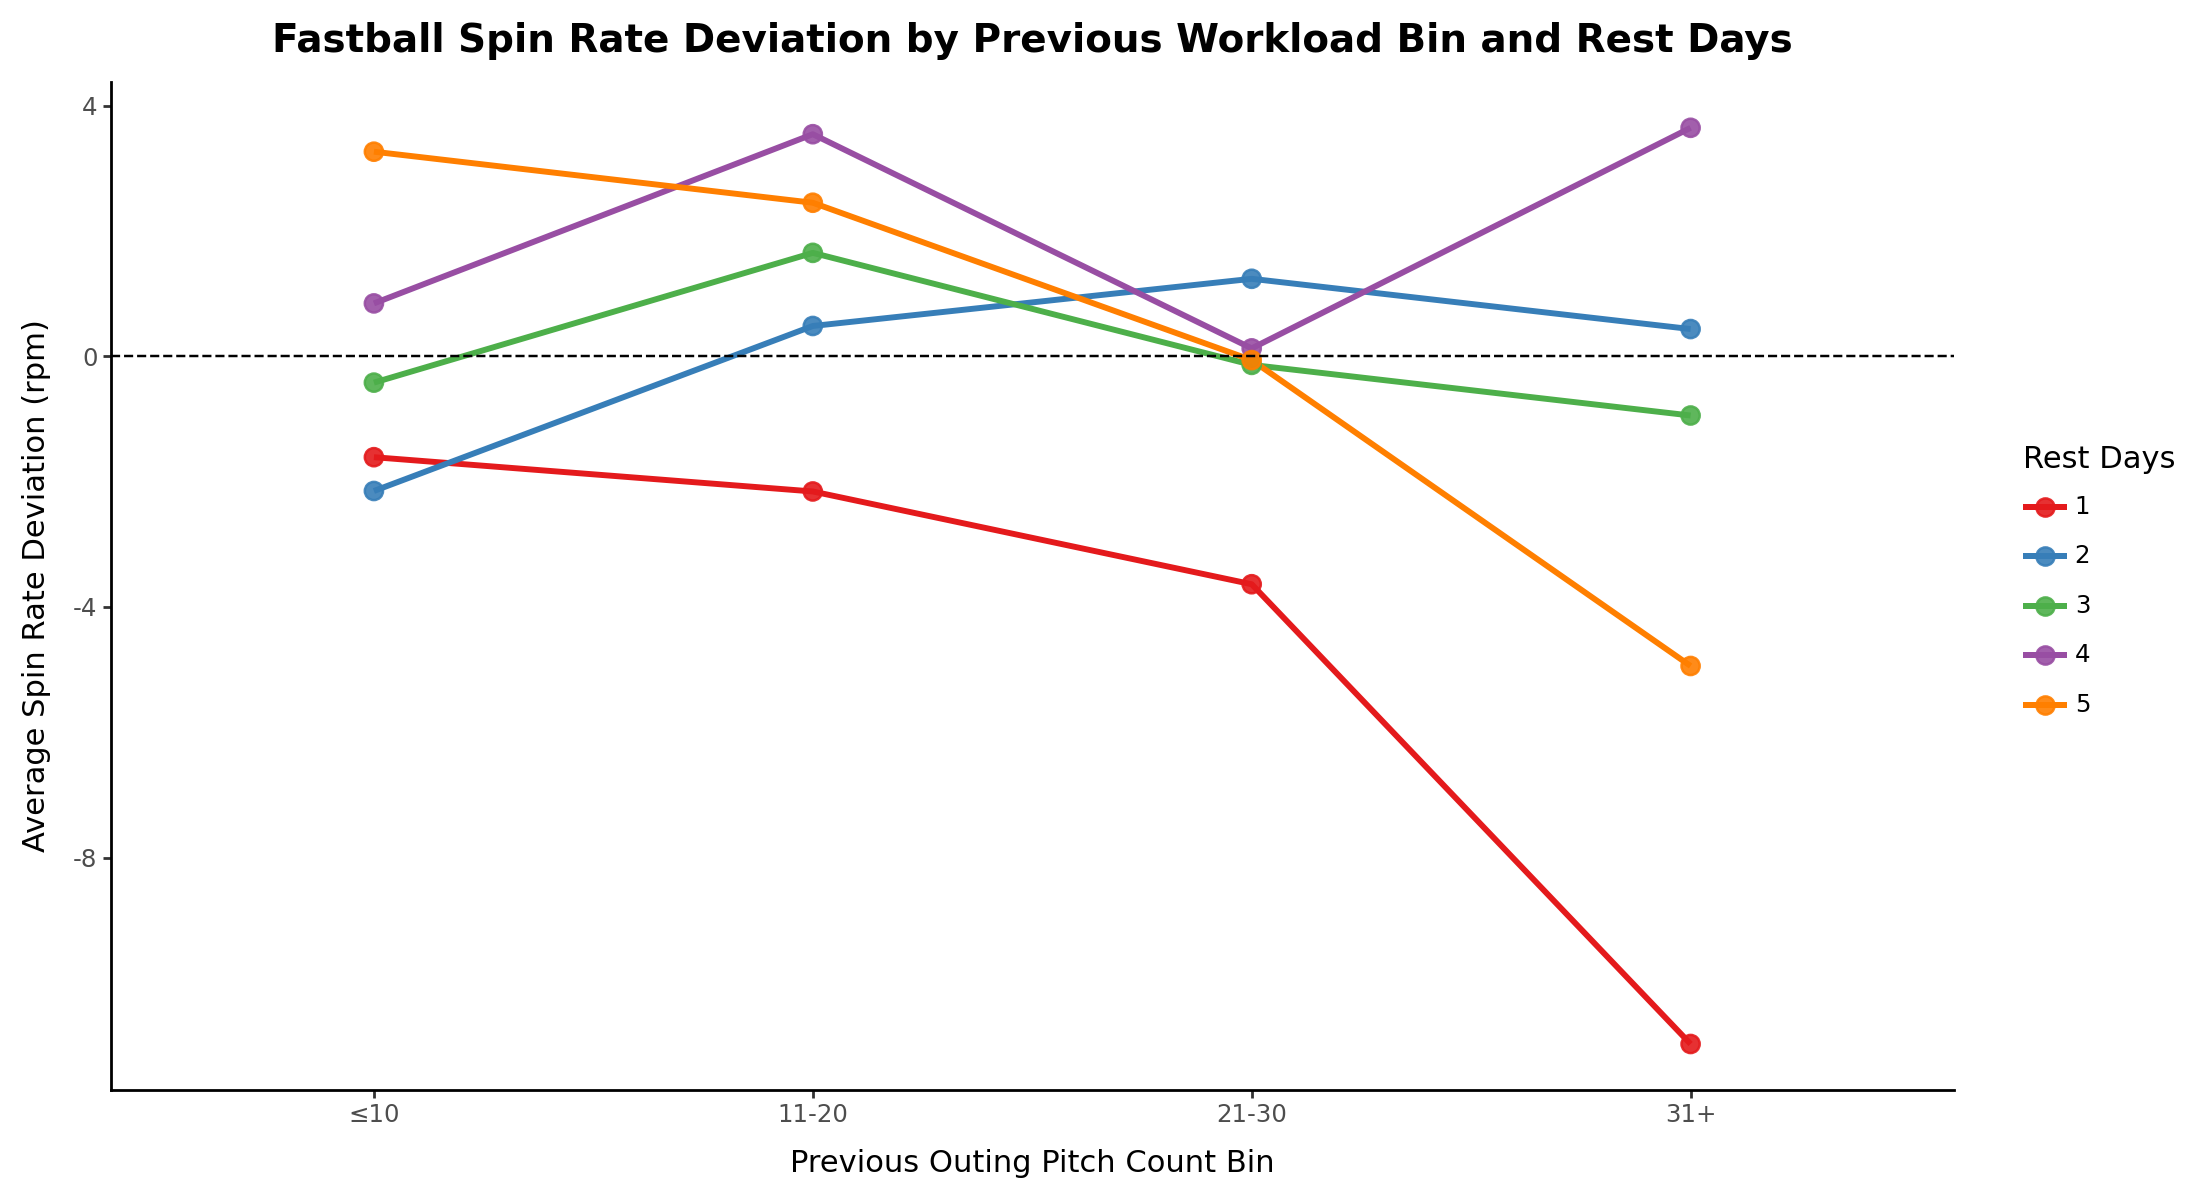

In [13]:
# Matching spin-rate chart: mean spin deviation by workload bin, grouped by rest days
spin_plot_data = (
    complete_outing_table
    .filter(
        pl.col("rest_days").is_between(1, 5)
        & pl.col("prev_pitch_bin").is_not_null()
        & pl.col("spin_deviation").is_not_null()
    )
    .group_by(["rest_days", "prev_pitch_bin"] )
    .agg([
        pl.mean("spin_deviation").alias("avg_spin_deviation"),
        pl.len().alias("n")
    ])
    .to_pandas()
)

bin_order = ["≤10", "11-20", "21-30", "31+"]
spin_plot_data["prev_pitch_bin"] = pd.Categorical(
    spin_plot_data["prev_pitch_bin"],
    categories=bin_order,
    ordered=True
)
spin_plot_data = spin_plot_data.sort_values(["rest_days", "prev_pitch_bin"]).reset_index(drop=True)

(
    ggplot(
        spin_plot_data,
        aes(
            x="prev_pitch_bin",
            y="avg_spin_deviation",
            group="factor(rest_days)",
            color="factor(rest_days)"
        )
    )
    + geom_line(size=1.2)
    + geom_point(size=3.2, alpha=0.9)
    + geom_hline(yintercept=0, linetype="dashed", color="black")
    + scale_color_brewer(type="qual", palette="Set1")
    + labs(
        title="Fastball Spin Rate Deviation by Previous Workload Bin and Rest Days",
        x="Previous Outing Pitch Count Bin",
        y="Average Spin Rate Deviation (rpm)",
        color="Rest Days"
    )
    + theme_classic()
    + theme(
        figure_size=(11, 6),
        legend_position="right",
        axis_text_x=element_text(rotation=0),
        plot_title=element_text(weight="bold", size=14),
        legend_key=element_rect(fill="white", color="white"),
    )
)

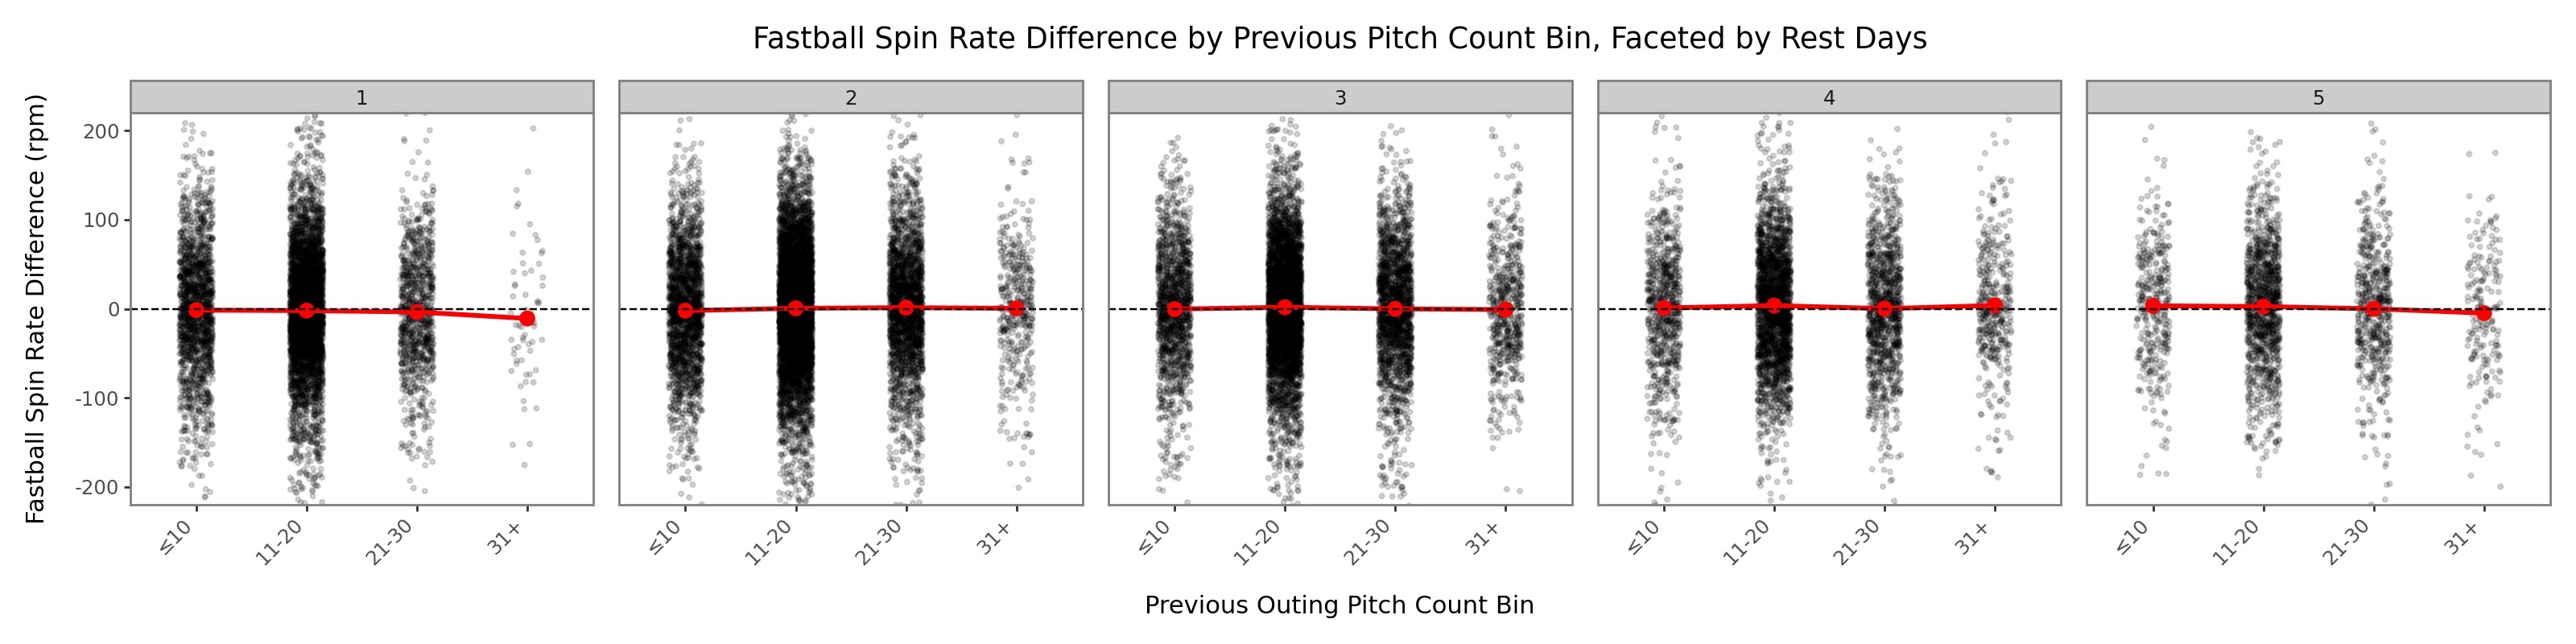

In [14]:
# Prepare data for spin faceted plot
spin_facet_data = (
    complete_outing_table
    .filter(
        pl.col("rest_days").is_between(1, 5)
        & pl.col("prev_pitch_bin").is_not_null()
        & pl.col("spin_deviation").is_not_null()
    )
    .to_pandas()
)

# Ensure correct categorical ordering
spin_facet_data["prev_pitch_bin"] = pd.Categorical(
    spin_facet_data["prev_pitch_bin"],
    categories=["≤10", "11-20", "21-30", "31+"],
    ordered=True
)

(
    ggplot(spin_facet_data, aes(x="prev_pitch_bin", y="spin_deviation"))
    + geom_jitter(alpha=0.15, width=0.15, size=0.7)
    + stat_summary(aes(group=1), fun_y=np.mean, geom="line", color="red", size=1.2)
    + stat_summary(fun_y=np.mean, geom="point", color="red", size=3)
    + geom_hline(yintercept=0, linetype="dashed")
    + coord_cartesian(ylim=(-200, 200))
    + facet_wrap("~rest_days", ncol=6)
    + labs(
        title="Fastball Spin Rate Difference by Previous Pitch Count Bin, Faceted by Rest Days",
        x="Previous Outing Pitch Count Bin",
        y="Fastball Spin Rate Difference (rpm)"
    )
    + theme(
        figure_size=(16, 4),
        axis_text_x=element_text(angle=45, hjust=1)
    )
)

In [15]:
slider_metrics = (
    relieverss
    .filter(pl.col("pitch_type_abbr") == "SL")
    .drop_nulls(["velocity", "spin_rate", "horizontal_movement", "vertical_movement", "pitcher_id", "game_id", "year"])
    .with_columns([
        ((pl.col("horizontal_movement").abs() + pl.col("vertical_movement").abs()) * 12).alias("total_movement")
    ])
    .group_by(["pitcher_id", "game_id", "year"])
    .agg([
        pl.mean("velocity").alias("mean_slider_velo"),
        pl.mean("spin_rate").alias("mean_slider_spin"),
        pl.mean("total_movement").alias("mean_slider_movement"),
        pl.len().alias("slider_pitch_count"),
    ])
    .filter(pl.col("slider_pitch_count") >= 3)
    .with_columns([
        pl.col("mean_slider_velo").mean().over(["pitcher_id", "year"]).alias("season_avg_slider_velo"),
        pl.col("mean_slider_spin").mean().over(["pitcher_id", "year"]).alias("season_avg_slider_spin"),
        pl.col("mean_slider_movement").mean().over(["pitcher_id", "year"]).alias("season_avg_slider_movement"),
    ])
    .with_columns([
        (pl.col("mean_slider_velo") - pl.col("season_avg_slider_velo")).alias("slider_velo_deviation"),
        (pl.col("mean_slider_spin") - pl.col("season_avg_slider_spin")).alias("slider_spin_deviation"),
        (pl.col("mean_slider_movement") - pl.col("season_avg_slider_movement")).alias("slider_movement_deviation"),
    ])
)

slider_outing_table = (
    complete_outing_table
    .select(["pitcher_id", "game_id", "rest_days", "prev_pitch_count", "prev_pitch_bin"])
    .join(
        slider_metrics.select([
            "pitcher_id", "game_id",
            "season_avg_slider_velo",
            "season_avg_slider_spin",
            "season_avg_slider_movement",
            "slider_pitch_count",
            "slider_velo_deviation",
            "slider_spin_deviation",
            "slider_movement_deviation"
        ]),
        on=["pitcher_id", "game_id"],
        how="inner"
    )
)

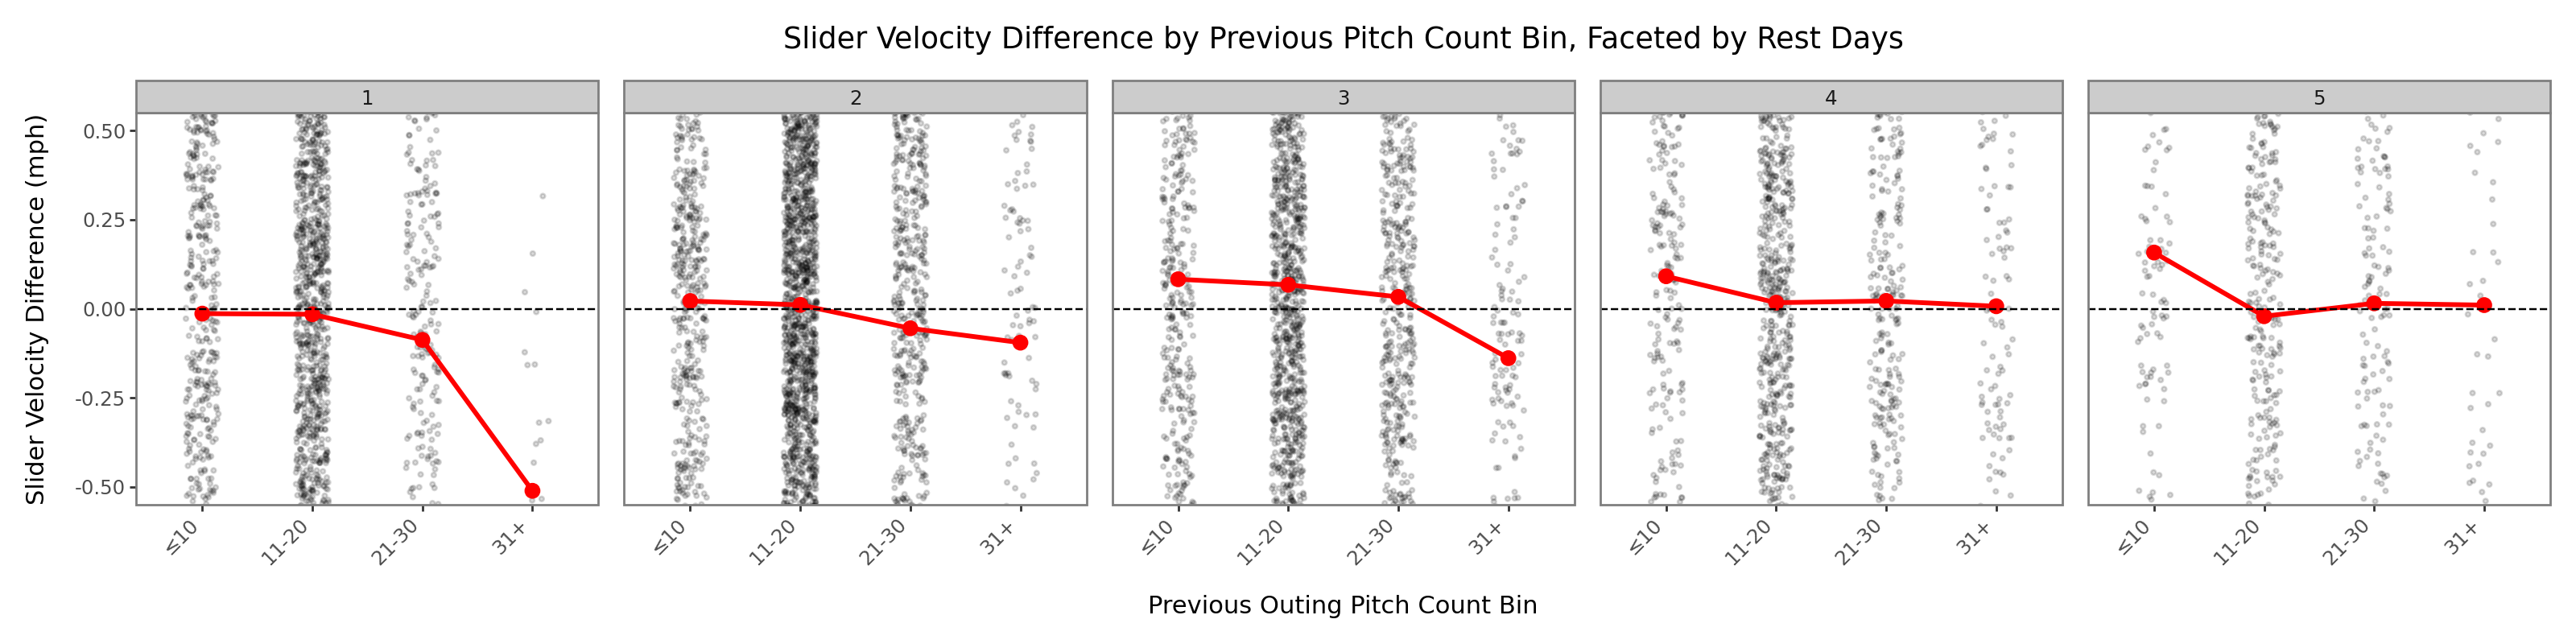

In [16]:
# Prepare data for slider velocity faceted plot
slider_velo_facet_data = (
    slider_outing_table
    .filter(
        pl.col("rest_days").is_between(1, 5)
        & pl.col("prev_pitch_bin").is_not_null()
        & pl.col("slider_velo_deviation").is_not_null()
    )
    .to_pandas()
)

# Ensure correct categorical ordering
slider_velo_facet_data["prev_pitch_bin"] = pd.Categorical(
    slider_velo_facet_data["prev_pitch_bin"],
    categories=["≤10", "11-20", "21-30", "31+"],
    ordered=True
)

(
    ggplot(slider_velo_facet_data, aes(x="prev_pitch_bin", y="slider_velo_deviation"))
    + geom_jitter(alpha=0.15, width=0.15, size=0.7)
    + stat_summary(aes(group=1), fun_y=np.mean, geom="line", color="red", size=1.2)
    + stat_summary(fun_y=np.mean, geom="point", color="red", size=3)
    + geom_hline(yintercept=0, linetype="dashed")
    + coord_cartesian(ylim=(-0.5, 0.5))
    + facet_wrap("~rest_days", ncol=6)
    + labs(
        title="Slider Velocity Difference by Previous Pitch Count Bin, Faceted by Rest Days",
        x="Previous Outing Pitch Count Bin",
        y="Slider Velocity Difference (mph)"
    )
    + theme(
        figure_size=(16, 4),
        axis_text_x=element_text(angle=45, hjust=1)
    )
)

In [17]:
# Compute heatmap data directly to include rest_days = 0
heatmap_df = (
    complete_outing_table
    .filter(
        pl.col("rest_days").is_between(1, 5)
        & pl.col("prev_pitch_bin").is_not_null()
        & pl.col("velo_deviation").is_not_null()
    )
    .group_by(["rest_days", "prev_pitch_bin"])
    .agg(pl.mean("velo_deviation").alias("avg_velo_difference"))
    .to_pandas()
)

heatmap_pivot = heatmap_df.pivot(
    index="prev_pitch_bin",
    columns="rest_days",
    values="avg_velo_difference"
)
heatmap_pivot = heatmap_pivot.reindex(["≤10", "11-20", "21-30", "31+"])


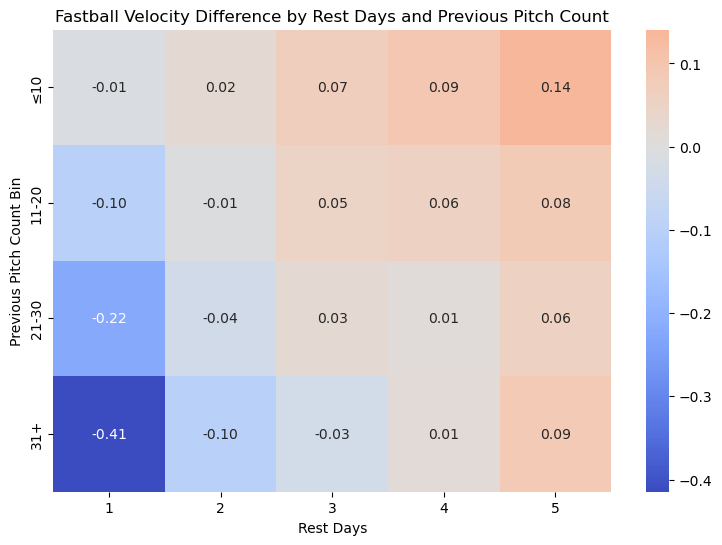

In [18]:

import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

sns.heatmap(
    heatmap_pivot,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Fastball Velocity Difference by Rest Days and Previous Pitch Count")
plt.xlabel("Rest Days")
plt.ylabel("Previous Pitch Count Bin")

plt.show()

In [19]:
(summary_table := pl.read_csv("data/rest_pitch_summary_table_days_bin.csv"))

rest_days,prev_pitch_bin,avg_velo_difference,avg_spin_difference,n
i64,str,f64,f64,i64
1,"""≤10""",-0.01,-2.0,1715
1,"""11-20""",-0.1,-2.0,4084
1,"""21-30""",-0.22,-4.0,974
1,"""31+""",-0.41,-11.0,64
2,"""≤10""",0.02,-2.0,2063
…,…,…,…,…
4,"""31+""",-0.0,3.0,463
5,"""≤10""",0.15,4.0,378
5,"""11-20""",0.08,2.0,1215


---
# Season-Long Workload Analysis

The previous analyses focused on short-term recovery between outings. The following sections examine cumulative fatigue effects over the course of the 6-month MLB season.

### Velocity Deviation by Month
A more granular view of how velocity changes month-by-month throughout the season.

In [20]:
# Plot velocity deviation by month
(
    ggplot(monthly_velocity, aes(x="month_name", y="avg_velo_deviation"))
    + geom_line(aes(group=1), color="steelblue", size=1.5)
    + geom_point(color="steelblue", size=4)
    + geom_hline(yintercept=0, linetype="dashed", color="red")
    + labs(
        title="Average Fastball Velocity Deviation by Month",
        x="Month",
        y="Average Velocity Deviation (mph)"
    )
    + theme(figure_size=(9, 5))
)

NameError: name 'monthly_velocity' is not defined

### Season Workload by Rest Days (Years Pooled)
This view ignores calendar year and summarizes typical in-season workload patterns by rest-day group.

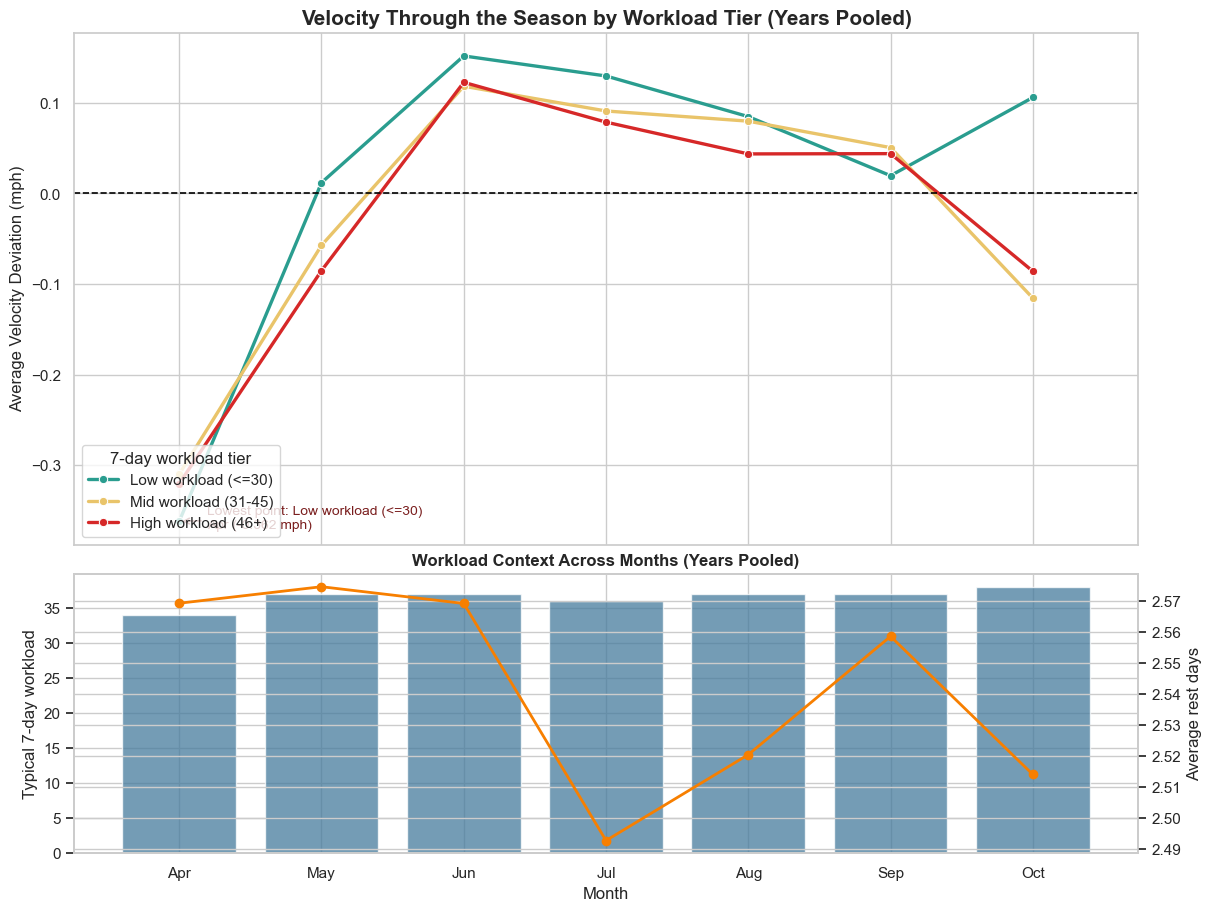

In [ ]:
# Build pooled season workload profile by rest days (ignore year)
season_workload_rest = (
    rolling_workload
    .filter(
        pl.col("pitches_prev_7d").is_not_null()
        & pl.col("rest_days").is_not_null()
        & pl.col("rest_days").is_between(1, 5)
    )
    .with_columns(pl.col("date").dt.month().alias("month"))
    .filter(pl.col("month").is_in([4, 5, 6, 7, 8, 9, 10]))
    .group_by(["month", "rest_days"])
    .agg([
        pl.col("pitches_prev_7d").median().alias("median_workload_7d"),
        pl.col("pitches_prev_7d").mean().alias("mean_workload_7d"),
        pl.len().alias("n")
    ])
    .to_pandas()
)

month_labels = {4: "Apr", 5: "May", 6: "Jun", 7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct"}
month_order = ["Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct"]

season_workload_rest["month_name"] = season_workload_rest["month"].map(month_labels)
season_workload_rest["month_name"] = pd.Categorical(
    season_workload_rest["month_name"],
    categories=month_order,
    ordered=True
)
season_workload_rest = season_workload_rest.sort_values(["rest_days", "month_name"])

# Story layer: velocity through season by workload tier (years pooled)
season_velocity_story = (
    rolling_workload
    .filter(
        pl.col("pitches_prev_7d").is_not_null()
        & pl.col("velo_deviation").is_not_null()
        & pl.col("rest_days").is_not_null()
        & pl.col("rest_days").is_between(1, 5)
    )
    .with_columns([
        pl.col("date").dt.month().alias("month"),
        pl.when(pl.col("pitches_prev_7d") <= 30)
        .then(pl.lit("Low workload (<=30)"))
        .when(pl.col("pitches_prev_7d") <= 45)
        .then(pl.lit("Mid workload (31-45)"))
        .otherwise(pl.lit("High workload (46+)"))
        .alias("workload_tier")
    ])
    .filter(pl.col("month").is_in([4, 5, 6, 7, 8, 9, 10]))
    .group_by(["month", "workload_tier"])
    .agg([
        pl.mean("velo_deviation").alias("avg_velo_deviation"),
        pl.median("pitches_prev_7d").alias("median_workload_7d"),
        pl.mean("rest_days").alias("mean_rest_days"),
        pl.len().alias("n")
    ])
    .filter(pl.col("n") >= 100)
    .to_pandas()
)

season_velocity_story["month_name"] = season_velocity_story["month"].map(month_labels)
season_velocity_story["month_name"] = pd.Categorical(
    season_velocity_story["month_name"],
    categories=month_order,
    ordered=True
)
tier_order = ["Low workload (<=30)", "Mid workload (31-45)", "High workload (46+)"]
season_velocity_story["workload_tier"] = pd.Categorical(
    season_velocity_story["workload_tier"],
    categories=tier_order,
    ordered=True
)
season_velocity_story = season_velocity_story.sort_values(["workload_tier", "month_name"])

# True monthly context from raw outings (not averaged from grouped rest bins)
month_context = (
    rolling_workload
    .filter(
        pl.col("pitches_prev_7d").is_not_null()
        & pl.col("rest_days").is_not_null()
        & pl.col("rest_days").is_between(1, 5)
    )
    .with_columns(pl.col("date").dt.month().alias("month"))
    .filter(pl.col("month").is_in([4, 5, 6, 7, 8, 9, 10]))
    .group_by("month")
    .agg([
        pl.col("pitches_prev_7d").median().alias("median_workload_7d"),
        pl.col("rest_days").mean().alias("mean_rest_days"),
        pl.len().alias("n")
    ])
    .to_pandas()
)
month_context["month_name"] = month_context["month"].map(month_labels)
month_context["month_name"] = pd.Categorical(
    month_context["month_name"],
    categories=month_order,
    ordered=True
)
month_context = month_context.sort_values("month_name")

worst_point = season_velocity_story.loc[season_velocity_story["avg_velo_deviation"].idxmin()]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1.2]},
    constrained_layout=True
)

# Panel 1: velocity story through season by workload tier
sns.lineplot(
    data=season_velocity_story,
    x="month_name",
    y="avg_velo_deviation",
    hue="workload_tier",
    marker="o",
    linewidth=2.4,
    palette=["#2A9D8F", "#E9C46A", "#D62828"],
    ax=axes[0]
)
axes[0].axhline(0, linestyle="--", color="black", linewidth=1.2)
axes[0].set_title("Velocity Through the Season by Workload Tier (Years Pooled)", fontsize=15, weight="bold")
axes[0].set_ylabel("Average Velocity Deviation (mph)")
axes[0].set_xlabel("")
axes[0].legend(title="7-day workload tier", loc="lower left")
axes[0].annotate(
    f"Lowest point: {worst_point['workload_tier']}\n{worst_point['month_name']} ({worst_point['avg_velo_deviation']:.3f} mph)",
    xy=(worst_point["month_name"], worst_point["avg_velo_deviation"]),
    xytext=(20, -5),
    textcoords="offset points",
    fontsize=10,
    color="#7A1E1E",
    arrowprops=dict(arrowstyle="->", color="#7A1E1E", lw=1.2)
)

# Panel 2: context for workload and rest through season
axes[1].bar(month_context["month_name"], month_context["median_workload_7d"], color="#457B9D", alpha=0.75)
axes[1].set_ylabel("Typical 7-day workload")
axes[1].set_xlabel("Month")
axes[1].set_title("Workload Context Across Months (Years Pooled)", fontsize=12, weight="bold")

ax2 = axes[1].twinx()
ax2.plot(month_context["month_name"], month_context["mean_rest_days"], color="#F77F00", marker="o", linewidth=2)
ax2.set_ylabel("Average rest days")

plt.show()

### Whiff Rate by Rest + Workload Bins
Use the same rest-day and workload bin structure to check whether missed-bat rates move with fatigue patterns.

In [ ]:
from plotnine import *
import polars as pl
import pandas as pd

# Load required tables if this cell is run independently
if "relieverss" not in globals():
    relieverss = pl.read_parquet("data/statcast_relievers_final.parquet")
if "complete_outing_table" not in globals():
    complete_outing_table = pl.read_parquet("data/complete_outing_table.parquet")
if "rolling_workload" not in globals():
    if "pitches_prev_7d" in complete_outing_table.columns:
        rolling_workload = complete_outing_table
    else:
        raise NameError(
            "rolling_workload is not defined and pitches_prev_7d is not in complete_outing_table. "
            "Run the season workload cell first to build rolling_workload."
        )

# Build outing-level whiff rate (whiffs / swings) from pitch outcomes
swing_events = [
    "swinging_strike",
    "swinging_strike_blocked",
    "foul",
    "foul_tip",
    "foul_bunt",
    "hit_into_play",
    "hit_into_play_no_out",
    "hit_into_play_score",
]
whiff_events = ["swinging_strike", "swinging_strike_blocked"]

outing_whiff = (
    relieverss
    .filter(pl.col("description").is_not_null())
    .with_columns([
        pl.col("description").is_in(swing_events).cast(pl.Int8).alias("is_swing"),
        pl.col("description").is_in(whiff_events).cast(pl.Int8).alias("is_whiff"),
    ])
    .group_by(["pitcher_id", "game_id"] )
    .agg([
        pl.sum("is_swing").alias("swings"),
        pl.sum("is_whiff").alias("whiffs"),
        pl.len().alias("total_pitches")
    ])
    .filter(pl.col("swings") > 0)
    .with_columns((pl.col("whiffs") / pl.col("swings") * 100).alias("whiff_rate"))
)

# 1) Whiff rate by previous outing pitch-count bin and rest days
whiff_rest_bins = (
    complete_outing_table
    .select(["pitcher_id", "game_id", "rest_days", "prev_pitch_bin"] )
    .join(
        outing_whiff.select(["pitcher_id", "game_id", "whiff_rate", "swings"]),
        on=["pitcher_id", "game_id"],
        how="inner"
    )
    .filter(
        pl.col("rest_days").is_between(1, 5)
        & pl.col("prev_pitch_bin").is_not_null()
    )
    .group_by(["rest_days", "prev_pitch_bin"] )
    .agg([
        pl.mean("whiff_rate").alias("avg_whiff_rate"),
        pl.sum("swings").alias("total_swings"),
        pl.len().alias("n_outings")
    ])
    .to_pandas()
)

pitch_bin_order = ["≤10", "11-20", "21-30", "31+"]
whiff_rest_bins["prev_pitch_bin"] = pd.Categorical(
    whiff_rest_bins["prev_pitch_bin"],
    categories=pitch_bin_order,
    ordered=True
)
whiff_rest_bins = whiff_rest_bins.sort_values(["rest_days", "prev_pitch_bin"]).reset_index(drop=True)

(
    ggplot(
        whiff_rest_bins,
        aes(
            x="prev_pitch_bin",
            y="avg_whiff_rate",
            group="factor(rest_days)",
            color="factor(rest_days)"
        )
    )
    + geom_line(size=1.2)
    + geom_point(size=3.2, alpha=0.9)
    + labs(
        title="Whiff Rate by Previous Pitch Count Bin and Rest Days",
        x="Previous Outing Pitch Count Bin",
        y="Average Whiff Rate (%)",
        color="Rest Days"
    )
    + scale_color_brewer(type="qual", palette="Set1")
    + theme_classic()
    + theme(
        figure_size=(10, 5),
        plot_title=element_text(weight="bold", size=14),
        legend_position="right",
        legend_key=element_rect(fill="white", color="white"),
    )
)

# 2) Whiff rate by 7-day rolling workload bins and rest days
whiff_workload_bins = (
    rolling_workload
    .select(["pitcher_id", "game_id", "rest_days", "pitches_prev_7d"] )
    .join(
        outing_whiff.select(["pitcher_id", "game_id", "whiff_rate", "swings"]),
        on=["pitcher_id", "game_id"],
        how="inner"
    )
    .filter(
        pl.col("rest_days").is_between(1, 5)
        & pl.col("pitches_prev_7d").is_not_null()
    )
    .with_columns(
        pl.when(pl.col("pitches_prev_7d") <= 20).then(pl.lit("0-20"))
        .when(pl.col("pitches_prev_7d") <= 40).then(pl.lit("21-40"))
        .when(pl.col("pitches_prev_7d") <= 60).then(pl.lit("41-60"))
        .otherwise(pl.lit("61+"))
        .alias("workload_7d_bin")
    )
    .group_by(["rest_days", "workload_7d_bin"] )
    .agg([
        pl.mean("whiff_rate").alias("avg_whiff_rate"),
        pl.sum("swings").alias("total_swings"),
        pl.len().alias("n_outings")
    ])
    .to_pandas()
)

workload_bin_order = ["0-20", "21-40", "41-60", "61+"]
whiff_workload_bins["workload_7d_bin"] = pd.Categorical(
    whiff_workload_bins["workload_7d_bin"],
    categories=workload_bin_order,
    ordered=True
)
whiff_workload_bins = whiff_workload_bins.sort_values(["rest_days", "workload_7d_bin"]).reset_index(drop=True)

(
    ggplot(
        whiff_workload_bins,
        aes(
            x="workload_7d_bin",
            y="avg_whiff_rate",
            group="factor(rest_days)",
            color="factor(rest_days)"
        )
    )
    + geom_line(size=1.2)
    + geom_point(size=3.2, alpha=0.9)
    + labs(
        title="Whiff Rate by 7-Day Workload Bin and Rest Days",
        x="Pitches Thrown in Previous 7 Days",
        y="Average Whiff Rate (%)",
        color="Rest Days"
    )
    + scale_color_brewer(type="qual", palette="Set1")
    + theme_classic()
    + theme(
        figure_size=(10, 5),
        plot_title=element_text(weight="bold", size=14),
        legend_position="right",
        legend_key=element_rect(fill="white", color="white"),
    )
)

# Quick table view for slide text
print("Whiff rate summary by rest-day x previous pitch bin")
display(whiff_rest_bins.round(2))

print("Whiff rate summary by rest-day x 7-day workload bin")
display(whiff_workload_bins.round(2))

NameError: name 'relieverss' is not defined